In [1]:
import json
import logging
import faster_coco_eval
from faster_coco_eval import COCO
from faster_coco_eval.extra import Curves
from faster_coco_eval.extra import PreviewResults
import matplotlib.pyplot as plt

print(f"{faster_coco_eval.__version__=}")

logging.root.setLevel("INFO")
logging.debug("Запись.")

faster_coco_eval.__version__='1.3.3'


In [2]:
def load(file):
    with open(file) as io:
        _data = json.load(io)
        
    return _data

In [3]:
GT = load('/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json')
prediction = load('/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino.bbox.json')

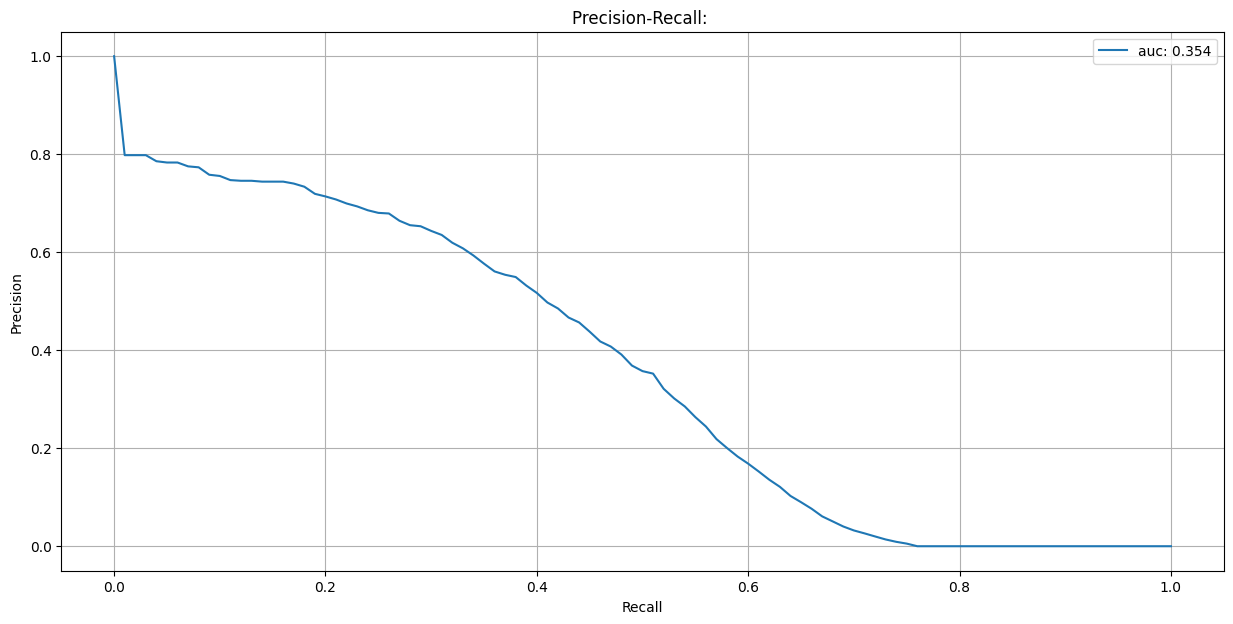

(<Figure size 1500x700 with 1 Axes>,
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 array([1.        , 0.79807692, 0.79807692, 0.79807692, 0.78571429,
        0.78306878, 0.78306878, 0.77522936, 0.77327935, 0.75812274,
        0.75562701, 0.74719101, 0.74580336, 0.74580336, 0.74404762,
        0.74404762, 0.74404762, 0.74011299, 0.73368607, 0.71915584,
   

In [4]:
threshold_iou = 0.5
iouType = 'bbox'

cocoGt = COCO(GT)
cocoDt = cocoGt.loadRes(prediction)

cur = Curves(cocoGt, cocoDt, iou_tresh=threshold_iou, iouType=iouType)
cur.plot_pre_rec(plotly_backend=True)

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Loading and preparing results...
DONE (t=9.99s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.12s).
Accumulating evaluation results...
DONE (t=0.80s).


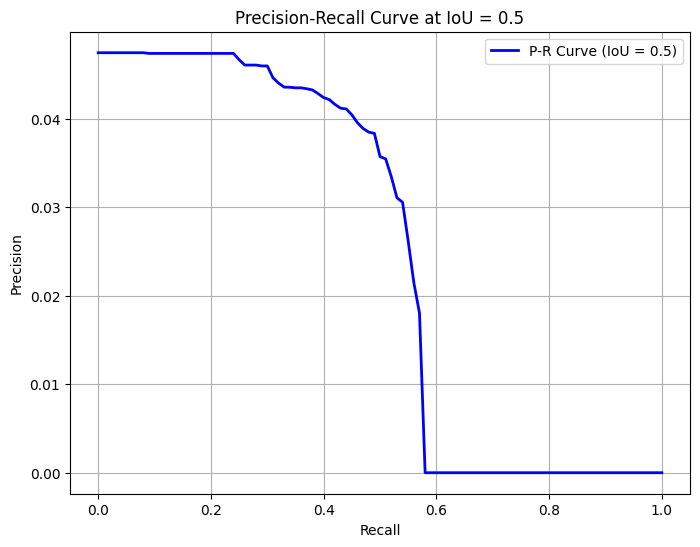

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Load the GT and prediction JSON files
gt_path = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json'  # Replace with your GT JSON path
pred_path = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino.bbox.json'  # Replace with your prediction JSON path

# Initialize COCO objects for GT and predictions
coco_gt = COCO(gt_path)
coco_pred = coco_gt.loadRes(pred_path)

# Initialize COCO evaluator
coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()


# Set the specific IoU threshold you want to use
desired_iou = 0.5  # Set your specific IoU threshold here
iou_thresholds = coco_eval.params.iouThrs
iou_index = np.where(np.isclose(iou_thresholds, desired_iou))[0][0]

# Extract precision and recall for the selected IoU threshold
precision_at_iou = coco_eval.eval['precision'][iou_index, :, 0, 0, 2]  # Averaging over categories and area
recall_at_iou = coco_eval.params.recThrs

# Plot P-R Curve at the specific IoU threshold
plt.figure(figsize=(8, 6))
plt.plot(recall_at_iou, precision_at_iou, label=f'P-R Curve (IoU = {desired_iou})', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve at IoU = {desired_iou}')
plt.legend(loc="upper right")
plt.grid()
plt.show()


In [2]:
coco_eval.summarize()

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.040
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.074
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.176
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.207
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np
import skimage.io as io
import pylab
pylab.rcParams['figure.figsize'] = (10.0, 8.0)

annType = ['segm','bbox','keypoints']
annType = annType[1]      #specify type here
prefix = 'person_keypoints' if annType=='keypoints' else 'instances'
# print 'Running demo for *%s* results.'%(annType)

#initialize COCO ground truth api
# dataDir='../'
# dataType='val2014'
annFile = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json'
cocoGt=COCO(annFile)

#initialize COCO detections api
# resFile='%s/results/%s_%s_fake%s100_results.json'
resFile = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino.bbox.json'
cocoDt=cocoGt.loadRes(resFile)

imgIds=sorted(cocoGt.getImgIds())
imgIds=imgIds[0:100]
imgId = imgIds[np.random.randint(100)]

# running evaluation
cocoEval = COCOeval(cocoGt,cocoDt,annType)
cocoEval.params.imgIds  = imgIds
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=6.75s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.85s).
Accumulating evaluation results...
DONE (t=0.24s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.061
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=7.22s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.71s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.161
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.484
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.054
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.046
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.196
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.033
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.153
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

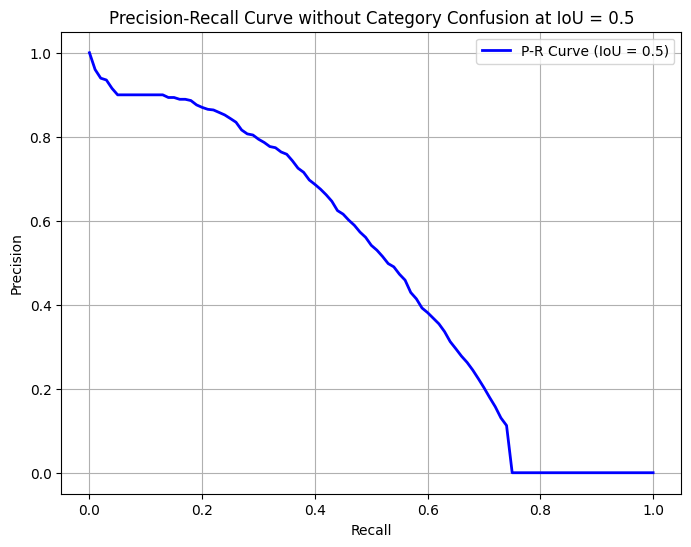

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import copy


# Load the GT and prediction JSON files
gt_path = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json'  # Replace with your GT JSON path
pred_path = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino_caption.bbox.json'  # Replace with your prediction JSON path

# Load ground truth and prediction JSON
with open(gt_path, 'r') as f:
    gt_data = json.load(f)
with open(pred_path, 'r') as f:
    pred_data = json.load(f)

# Create copies and set category_id to 1 for all annotations and predictions
gt_data_no_confusion = copy.deepcopy(gt_data)
pred_data_no_confusion = copy.deepcopy(pred_data)

for ann in gt_data_no_confusion['annotations']:
    ann['category_id'] = 1  # Set all ground truth annotations to category 1

for ann in pred_data_no_confusion:
    ann['category_id'] = 1  # Set all prediction annotations to category 1

# Save modified JSON files
with open('gt_no_confusion.json', 'w') as f:
    json.dump(gt_data_no_confusion, f)
with open('pred_no_confusion.json', 'w') as f:
    json.dump(pred_data_no_confusion, f)

# Load the modified GT and prediction files in COCO
coco_gt = COCO('gt_no_confusion.json')
coco_pred = coco_gt.loadRes('pred_no_confusion.json')

# Initialize COCO evaluator
coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Set the IoU threshold you want to use for plotting
desired_iou = 0.5  # Adjust this IoU as needed
iou_thresholds = coco_eval.params.iouThrs
iou_index = np.where(np.isclose(iou_thresholds, desired_iou))[0][0]

# Extract precision and recall for the selected IoU threshold
precision_at_iou = coco_eval.eval['precision'][iou_index, :, 0, 0, 2]  # Averaging over categories and area
recall_at_iou = coco_eval.params.recThrs

# Plot P-R Curve at the specific IoU threshold
plt.figure(figsize=(8, 6))
plt.plot(recall_at_iou, precision_at_iou, label=f'P-R Curve (IoU = {desired_iou})', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve without Category Confusion at IoU = {desired_iou}')
plt.legend(loc="upper right")
plt.grid()
plt.show()
